### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy import stats

np.random.seed(42)

gamma_dist = stats.gamma(1, scale=1)
campione = gamma_dist.rvs(size=1000)



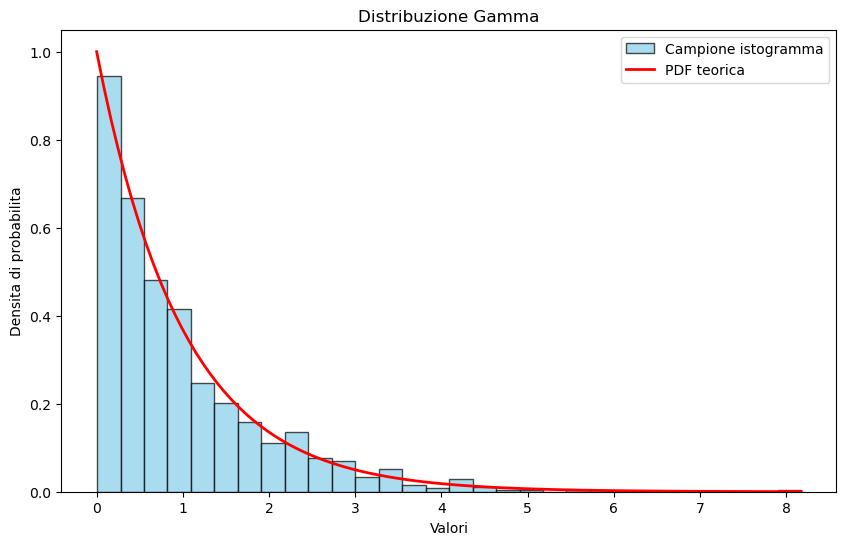

In [14]:
fig, ax = plt.subplots(figsize= (10, 6))

ax.hist(campione, bins= 30, density= True, alpha= 0.7, color= 'skyblue',
        edgecolor= 'black', label= 'Campione istogramma')

x = np.linspace(0, max(campione), 100)
pdf_teorica = gamma_dist.pdf(x)

ax.plot(x, pdf_teorica, 'r-', linewidth= 2, label= 'PDF teorica')
ax.set_xlabel('Valori')
ax.set_ylabel('Densita di probabilita')
ax.set_title('Distribuzione Gamma')
ax.legend()

plt.show()


In [15]:
shape_stimato, loc_stimato, scale_stimato = stats.gamma.fit(campione)
print(shape_stimato, loc_stimato, scale_stimato)

errore = abs(shape_stimato - 1)
print(errore)

0.9596112510552852 0.004642784066342884 1.0074484001678692
0.04038874894471478


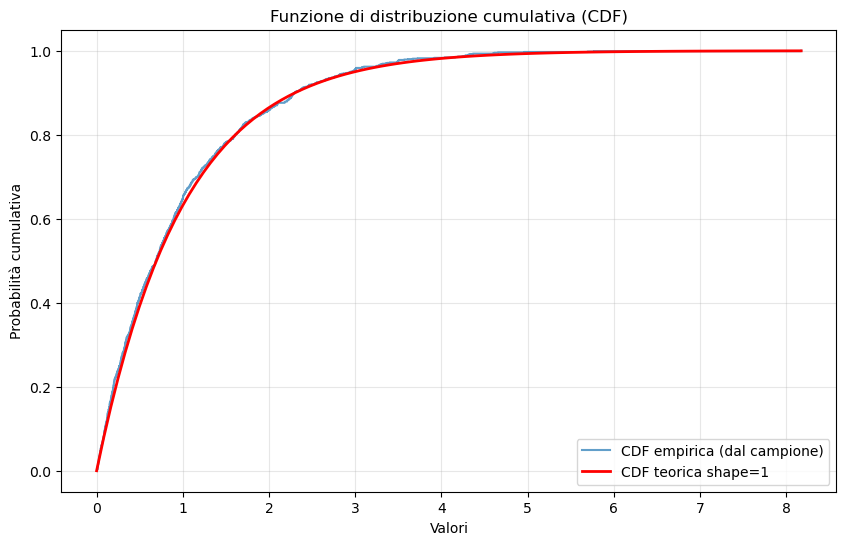


Probabilità che un valore sia ≤ 1.5: 0.7769 (cioè 77.7%)


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

# CDF empirica (dal campione)
x_sorted = np.sort(campione)
y_cdf_empirica = np.arange(1, len(campione)+1) / len(campione)
ax.step(x_sorted, y_cdf_empirica, where='post', alpha=0.7, 
        label='CDF empirica (dal campione)')

# CDF teorica
x_teorica = np.linspace(0, max(campione), 100)
cdf_teorica = gamma_dist.cdf(x_teorica)
ax.plot(x_teorica, cdf_teorica, 'r-', linewidth=2, 
        label=f'CDF teorica shape=1')

ax.set_xlabel('Valori')
ax.set_ylabel('Probabilità cumulativa')
ax.set_title('Funzione di distribuzione cumulativa (CDF)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

# Esempio di lettura della CDF
x_test = 1.5
prob = gamma_dist.cdf(x_test)
print(f"\nProbabilità che un valore sia ≤ {x_test}: {prob:.4f} (cioè {prob*100:.1f}%)")

### **2. Filtra i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

In [1]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt



### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [ ]:
import pandas as pd
from scipy import stats

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df




,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


/tmp/ipykernel_264638/196954640.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df['mpg'], df['disp']], labels=['mpg (consumo)', 'disp (cilindrata)'])


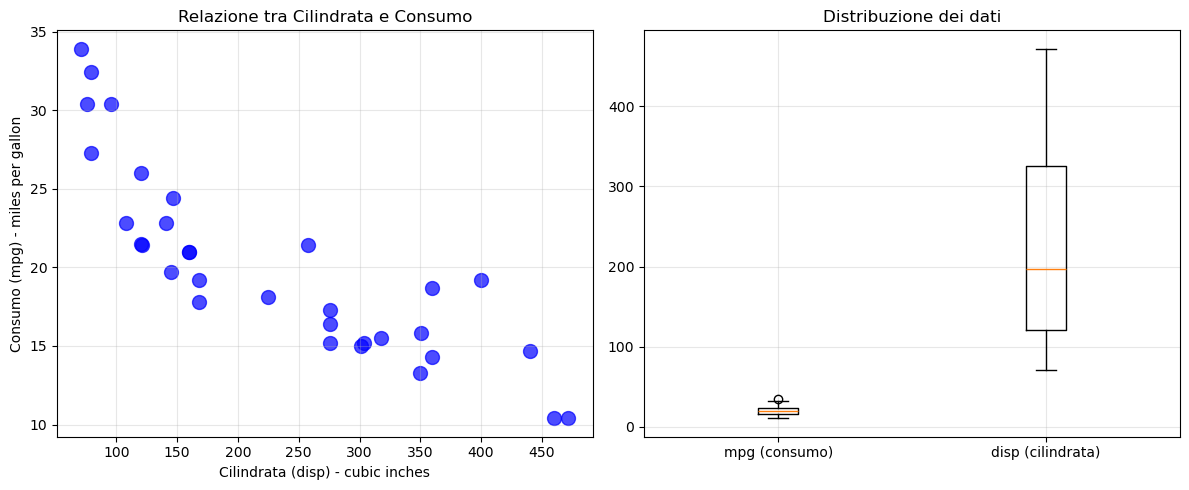


Correlazione tra mpg e disp: -0.848


In [19]:
# Visualizzazione dei dati
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['disp'], df['mpg'], alpha=0.7, s=100, c='blue')
axes[0].set_xlabel('Cilindrata (disp) - cubic inches')
axes[0].set_ylabel('Consumo (mpg) - miles per gallon')
axes[0].set_title('Relazione tra Cilindrata e Consumo')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([df['mpg'], df['disp']], labels=['mpg (consumo)', 'disp (cilindrata)'])
axes[1].set_title('Distribuzione dei dati')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcoliamo la correlazione
correlazione = df['mpg'].corr(df['disp'])
print(f"\nCorrelazione tra mpg e disp: {correlazione:.3f}")

In [20]:
x = df['mpg'].values
y = df['disp'].values

pendenza, intercetta, r_value, p_value, std_err = stats.linregress(x, y)

print(f'Pendenza: {pendenza:.4f}, Intercetta: {intercetta:.2f}, r_value:{r_value}, p_value:{p_value}')

Pendenza: -17.4291, Intercetta: 580.88, r_value:-0.8475513792624785, p_value:9.380326537381571e-10
